# Benchmark — Escalera de ablación del buscador semántico híbrido

**Proyecto:** Buscador semántico para reportes de la plataforma (GovTech / SUID).
**Notebook:** evaluación comparativa (benchmark) de cinco configuraciones de
recuperación sobre un protocolo *known-item*. Todo el código está **inline**: métricas,
índice léxico (BM25), índice denso, codificador, fusión (RRF), realce por entidad, las
cinco configuraciones y la estadística. Ejecutar el notebook reproduce el experimento de
punta a punta.

## 1. Contexto

### 1.1 El problema

La plataforma genera reportes cuya búsqueda actual es léxica (coincidencia exacta de
palabras): falla cuando el usuario describe una necesidad con otras palabras o busca por
**nombre propio** (un deportista, una institución). El objetivo es un **buscador
semántico híbrido** que combine la señal léxica (BM25) con una representación densa
(embeddings) y metadatos de una **ontología** del dominio, y medir cuánto aporta cada
componente.

### 1.2 Datos y variables

El corpus (`corpus/corpus_v1.jsonl`, 17 reportes + artefactos) lo construye
`experimentos/preprocess_corpus.py` (separa PII a un *gazetteer*, enriquece cada
documento con la ontología y produce los campos indexables). Diccionario de los campos
que usa la recuperación:

- `id`: identificador del documento (reporte).
- `titulo`: título del reporte.
- `descripcion`: texto base del reporte. Lo usan los peldaños **sin** ontología.
- `texto_indexable`: descripción **enriquecida** con φ(o_d) = metadatos de la ontología
  (clases, sinónimos, entidades). Lo usan los peldaños **con** ontología.
- `metadatos_ontologia.entidades_principales`: clases de entidad del documento (para el
  realce).
- `nombre_propio_buscable`: si el reporte es direccionable por nombre propio.
- `prioridad`, `cdr`: metadatos de demanda (trazabilidad, no entran a la recuperación).

### 1.3 Objetivo y preguntas de investigación

Objetivo: determinar la mejor combinación de señales para recuperar el reporte correcto,
con énfasis en consultas de **entidad exacta / nombre propio**. Preguntas:

| # | Pregunta |
|---|---|
| P1 | ¿El híbrido supera a BM25 y al denso puro? |
| P2 | ¿La ventaja del híbrido se concentra en *entidad exacta / nombre propio*? (hipótesis central) |
| P3 | ¿Inyectar metadatos de la ontología mejora el denso y el híbrido? |
| P4 | Efecto del tamaño/solapamiento de fragmento (barrido ortogonal). |
| P5 | ¿El realce suave por entidad mejora el top-k? |
| P6 | Mejor equilibrio efectividad/latencia/memoria y dimensión Matryoshka (ver notebook P6). |

### 1.4 Marco de evaluación: ¿hubo entrenamiento y prueba?

**Esto es recuperación de información (IR), no aprendizaje supervisado.** Es importante
para leer bien los números:

- **No hay entrenamiento con estos datos.** El codificador `jina-embeddings-v3` está
  **preentrenado y congelado**: solo se usa en *inferencia*. No se ajusta ni un peso con
  el corpus ni con las consultas. **BM25 no se entrena** (solo cuenta frecuencias).
- **No hay partición train/test** porque nada aprende de las consultas: el corpus es el
  **índice** y las consultas son el **conjunto de evaluación**.
- **Hiperparámetros estándar** (BM25 `k1=1.5, b=0.75`; RRF `k=60`; realce `λ=0.2`), no
  ajustados sobre este conjunto → no hay sobreajuste a la métrica.
- **Protocolo *known-item*:** cada consulta se construye desde artefactos reales
  (títulos, entidades y sinónimos de la ontología) y apunta a **un reporte objetivo
  conocido** (grado 2). Nombres propios **sintéticos**.
- **Limitación honesta:** como las consultas se derivan de los propios documentos,
  comparten vocabulario con ellos. El **valor absoluto** de nDCG@10 **no** es "precisión
  en producción"; lo válido y defendible es la **comparación relativa entre
  configuraciones** (por eso el diseño es una **ablación**: encender/apagar un componente
  a la vez).

## 2. Preparación del entorno

**Contexto y Objetivo.** Cargar librerías, localizar rutas y leer la configuración única
del experimento (`experimentos/config.yaml`). Solo se leen datos; **todo el cómputo vive
en este notebook**.

In [1]:
import json, sys, time, math, re, unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy import stats as sp_stats

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
EXP = RAIZ / "experimentos"

cfg = yaml.safe_load((EXP / "config.yaml").read_text(encoding="utf-8"))
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
SEMILLA = cfg["evaluacion"]["semilla"]
print("Encoder configurado:", cfg["encoder"]["tipo"], "→", cfg["encoder"]["modelo_st"])
print("BM25:", cfg["bm25"], "| RRF k =", cfg["fusion"]["k_rrf"], "| realce λ =", cfg["realce"]["lambda"])

Encoder configurado: sentence-transformer → jinaai/jina-embeddings-v3
BM25: {'k1': 1.5, 'b': 0.75} | RRF k = 60 | realce λ = 0.2


## 3. Datos

### 3.1 Carga del corpus

**Descripción Técnica.** Se cargan el corpus indexable y la ontología del dominio.

In [2]:
def cargar_jsonl(ruta: Path) -> list[dict]:
    return [json.loads(l) for l in ruta.read_text(encoding="utf-8").splitlines() if l.strip()]

docs = cargar_jsonl(EXP / cfg["rutas"]["corpus"])
ontologia = yaml.safe_load((EXP / cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))
print(f"{len(docs)} documentos en el corpus.")

17 documentos en el corpus.


### 3.2 Exploración del corpus

**Interpretación de Resultados.** Vista compacta de los reportes y contraste entre la
`descripcion` (sin ontología) y el `texto_indexable` (enriquecido). El enriquecimiento
añade clases, sinónimos y entidades: esa es la señal que aíslan los peldaños 2 y 4 (P3).

In [3]:
pd.DataFrame([{
    "id": d["id"], "titulo": d["titulo"][:42],
    "prioridad": d.get("prioridad"), "cdr": d.get("cdr"),
    "nombre_propio": d.get("nombre_propio_buscable", False),
    "entidades": ", ".join(d["metadatos_ontologia"].get("entidades_principales", []))[:34],
} for d in docs])

,id,titulo,prioridad,cdr,nombre_propio,entidades
0,ri_001_reporte_de_promocion_de_deportistas,Reporte de Promoción de Deportistas,Alta,4295,True,"Deportista, Disciplina Deportiva,"
1,ri_002_reporte_de_grupos,Reporte de Grupos,Alta,1445,True,"Disciplina Deportiva, Etapa/Fase,"
2,ri_003_reporte_de_personal_de_apoyo,Reporte de Personal de Apoyo,Alta,965,True,"Deportista, Disciplina Deportiva,"
3,ri_004_reporte_de_documentacion_de_deportistas,Reporte de Documentación de Deportistas,Alta,592,True,"Deportista, Disciplina Deportiva,"
4,ri_005_reporte_de_participacion,Reporte de Participación,Alta,532,True,"Deportista, Disciplina Deportiva,"
5,ri_006_reporte_individual_de_deportistas,Reporte Individual de Deportistas,Media,397,True,"Deportista, Disciplina Deportiva,"
6,ri_007_reporte_sobre_resumen_del_tablero_de_co...,Reporte sobre Resumen del Tablero de Contr,Media,307,False,"Deportista, Disciplina Deportiva,"
7,ri_008_reporte_de_instituciones,Reporte de Instituciones,Media,191,True,"Institución, Ubicación Geográfica"
8,ri_009_reporte_de_progreso_y_cumplimiento_de_m...,Reporte de Progreso y Cumplimiento de Meta,Media,96,False,Ubicación Geográfica
9,ri_010_reporte_sobre_distribucion_de_usuarios,Reporte sobre Distribución de Usuarios,Baja,58,False,


In [4]:
ej = docs[0]
print("ID:", ej["id"], "|", ej["titulo"], "\n")
print("descripcion (sin ontología):\n ", ej["descripcion"][:280], "...\n")
print("texto_indexable (enriquecido φ(o_d)):\n ", ej["texto_indexable"][:280], "...")

ID: ri_001_reporte_de_promocion_de_deportistas | Reporte de Promoción de Deportistas 

descripcion (sin ontología):
  El Reporte de Promoción de Deportistas es uno de los reportes del sistema de gestión deportiva. Se construye combinando información de Reporte Individual de Deportistas, Reporte de Participantes, Fases del Evento, Registro de Promociones y Reporte de Personal de Apoyo. En el peri ...

texto_indexable (enriquecido φ(o_d)):
  El Reporte de Promoción de Deportistas es uno de los reportes del sistema de gestión deportiva. Se construye combinando información de Reporte Individual de Deportistas, Reporte de Participantes, Fases del Evento, Registro de Promociones y Reporte de Personal de Apoyo. En el peri ...


### 3.3 Conjunto de evaluación (protocolo *known-item*)

**Contexto y Objetivo.** Construir las consultas de prueba y sus juicios de relevancia.

**Descripción Técnica.** Cada consulta apunta a un reporte objetivo (grado 2) y puede
añadir secundarios (grado 1). Cuatro estratos: *entidad_exacta*, *ambigua*,
*documento_largo* y *competencias*. Las de competencias tienen qrel vacío **a propósito**:
miden el *vacío de cobertura* de la v1. Código equivalente a
`experimentos/generar_consultas.py`, incluido aquí para que el protocolo sea visible.

In [5]:
NOMBRES = ["Andrés Torres", "María Restrepo", "Julián Gómez", "Valentina Ríos"]        # sintéticos
INSTITUCIONES = ["Colegio San Marcos", "Club Deportivo El Faro", "Liga Atlántico"]     # sintéticos

def id_por_palabra(docs, *claves):
    for d in docs:
        if all(c in d["titulo"].lower() for c in claves):
            return d["id"]
    return None

def construir_consultas(docs):
    ids = {k: id_por_palabra(docs, k) for k in
           ["promoción","grupos","personal","documentación","participación","instituciones",
            "metas","tablero","individual","delegaciones","federación","distribución"]}
    consultas, qrels, cont = [], {}, 0
    def add(texto, estrato, objetivo, nombre_propio=False, secundarios=None):
        nonlocal cont; cont += 1
        qid = f"q{cont:03d}"
        consultas.append({"id": qid, "texto": texto, "estrato": estrato,
                          "reporte_objetivo": objetivo, "menciona_nombre_propio": nombre_propio})
        rel = {}
        if objetivo: rel[objetivo] = 2.0
        for s in (secundarios or []):
            if s and s != objetivo: rel[s] = 1.0
        qrels[qid] = rel
    for nom in NOMBRES:
        add(f"estado de promoción de {nom}", "entidad_exacta", ids["promoción"], True)
        add(f"en qué fase va el deportista {nom}", "entidad_exacta", ids["promoción"], True)
    for inst in INSTITUCIONES:
        add(f"reporte de la institución {inst}", "entidad_exacta", ids["instituciones"], True, [ids["grupos"]])
    add("documentación del deportista Julián Gómez", "entidad_exacta", ids["documentación"], True)
    add("grupos de la institución Colegio San Marcos", "entidad_exacta", ids["grupos"], True, [ids["instituciones"]])
    add("personal de apoyo del deportista Andrés Torres", "entidad_exacta", ids["personal"], True)
    add("intención de participación de María Restrepo", "entidad_exacta", ids["participación"], True)
    add("cumplimiento de metas del deportista Valentina Ríos", "entidad_exacta", ids["metas"], True)
    add("reporte individual del deportista Julián Gómez", "entidad_exacta", ids["individual"], True)
    for term, obj in [("grupos","grupos"),("avance","promoción"),("documentos","documentación"),
                      ("participación","participación"),("personal","personal"),("metas","metas"),
                      ("instituciones","instituciones"),("promoción","promoción"),("tablero","tablero"),
                      ("etapas","promoción"),("delegaciones","delegaciones"),("federaciones","federación"),
                      ("distribución","distribución")]:
        add(term, "ambigua", ids[obj])
    add("quiero ver en qué etapa está cada deportista y si ya cumplió los requisitos para pasar a la siguiente fase de la competencia","documento_largo",ids["promoción"])
    add("necesito el listado de deportistas de una institución con el estado de su documentación al día","documento_largo",ids["documentación"],None,[ids["grupos"]])
    add("cómo saber qué grupos o delegaciones tiene registrada cada institución y su personal de apoyo","documento_largo",ids["grupos"],None,[ids["personal"]])
    add("resumen de cuántos deportistas han sido promovidos, rechazados o siguen pendientes en el evento","documento_largo",ids["promoción"])
    add("reporte con las metas de cada federación y su nivel de cumplimiento por región","documento_largo",ids["metas"])
    add("quiénes manifestaron intención de participar y cómo se distribuyen por delegación","documento_largo",ids["participación"])
    add("panorama general del tablero de control con los indicadores de la plataforma","documento_largo",ids["tablero"])
    add("necesito el personal de apoyo, entrenadores y acompañantes asignados a cada grupo","documento_largo",ids["personal"])
    add("cómo va la distribución de usuarios registrados en el sistema","documento_largo",ids["distribución"])
    add("estado de la documentación y los soportes cargados por cada deportista para habilitar su promoción","documento_largo",ids["documentación"],None,[ids["promoción"]])
    for texto in ["Atletismo Pre-Juvenil en Región Caribe 1","resultados de natación en fase regional",
                  "disciplinas de la categoría juvenil en los juegos nacionales",
                  "qué pruebas hay de atletismo en la región pacífico",
                  "resultados de la competencia de la fase departamental",
                  "ranking de la prueba de ciclismo en la región centro",
                  "eventos deportivos y sus fases de competencia",
                  "clasificados de la disciplina de baloncesto por región",
                  "marcas y resultados de la final nacional de atletismo",
                  "competencias de para-deporte por clasificación funcional",
                  "cuántos participantes hay por disciplina en cada región"]:
        add(texto, "competencias", None)
    return consultas, qrels

consultas, qrels = construir_consultas(docs)
est = Counter(c["estrato"] for c in consultas)
print("Total consultas:", len(consultas))
for e, n in est.items():
    print(f"  {e:16s} {n:2d}  ({100*n/len(consultas):.0f}%)")
print("Con documento relevante en v1 (con gold):", sum(1 for q in qrels.values() if q))

Total consultas: 51
  entidad_exacta   17  (33%)
  ambigua          13  (25%)
  documento_largo  10  (20%)
  competencias     11  (22%)
Con documento relevante en v1 (con gold): 40


In [6]:
pd.DataFrame(consultas).groupby("estrato").head(3)[
    ["id","estrato","texto","reporte_objetivo","menciona_nombre_propio"]].reset_index(drop=True)

,id,estrato,texto,reporte_objetivo,menciona_nombre_propio
0,q001,entidad_exacta,estado de promoción de Andrés Torres,ri_001_reporte_de_promocion_de_deportistas,True
1,q002,entidad_exacta,en qué fase va el deportista Andrés Torres,ri_001_reporte_de_promocion_de_deportistas,True
2,q003,entidad_exacta,estado de promoción de María Restrepo,ri_001_reporte_de_promocion_de_deportistas,True
3,q018,ambigua,grupos,ri_002_reporte_de_grupos,False
4,q019,ambigua,avance,ri_001_reporte_de_promocion_de_deportistas,False
5,q020,ambigua,documentos,ri_004_reporte_de_documentacion_de_deportistas,False
6,q031,documento_largo,quiero ver en qué etapa está cada deportista y...,ri_001_reporte_de_promocion_de_deportistas,False
7,q032,documento_largo,necesito el listado de deportistas de una inst...,ri_004_reporte_de_documentacion_de_deportistas,None
8,q033,documento_largo,cómo saber qué grupos o delegaciones tiene reg...,ri_002_reporte_de_grupos,None
9,q041,competencias,Atletismo Pre-Juvenil en Región Caribe 1,NaN,False


## 4. Metodología: componentes del recuperador

Cada componente se presenta con su **Contexto y Objetivo** y su **Descripción Técnica**
(el código). La *Interpretación de Resultados* se hace en la sección 6, ya con métricas.

### 4.1 Métricas de recuperación

**Contexto y Objetivo.** Cuantificar la calidad de un ranking frente a los juicios de
relevancia. La métrica principal es **nDCG@10** (premia colocar el documento relevante
arriba); se acompañan Recall@100, MRR@10, P@10 y AP@100.

**Descripción Técnica.** nDCG con ganancia exponencial `2^rel − 1`. Incluye auto-test.

In [7]:
def _grado(qrel, doc): return float(qrel.get(doc, 0.0))
def dcg(ranking, qrel, k):
    return sum((2.0**_grado(qrel,d)-1.0)/math.log2(i+1)
               for i,d in enumerate(ranking[:k],1) if _grado(qrel,d)>0)
def ndcg(ranking, qrel, k):
    ideal = sorted((g for g in qrel.values() if g>0), reverse=True)
    idcg = sum((2.0**g-1.0)/math.log2(i+1) for i,g in enumerate(ideal[:k],1))
    return 0.0 if idcg==0 else dcg(ranking,qrel,k)/idcg
def recall(ranking, qrel, k):
    rel = {d for d,g in qrel.items() if g>0}
    return 0.0 if not rel else sum(1 for d in ranking[:k] if d in rel)/len(rel)
def mrr(ranking, qrel, k):
    for i,d in enumerate(ranking[:k],1):
        if _grado(qrel,d)>0: return 1.0/i
    return 0.0
def precision(ranking, qrel, k):
    return 0.0 if k==0 else sum(1 for d in ranking[:k] if _grado(qrel,d)>0)/k
def average_precision(ranking, qrel, k):
    rel = {d for d,g in qrel.items() if g>0}
    if not rel: return 0.0
    ac, suma = 0, 0.0
    for i,d in enumerate(ranking[:k],1):
        if d in rel: ac+=1; suma+=ac/i
    return suma/min(len(rel),k)
def tiene_gold(qrel): return any(g>0 for g in qrel.values())

assert ndcg(["a","b","c"], {"a":1.0}, 10) == 1.0
assert abs(ndcg(["b","a","c"], {"a":1.0}, 10) - 1/math.log2(3)) < 1e-9
assert mrr(["b","a"], {"a":1.0}, 10) == 0.5
assert recall(["a","x"], {"a":1.0,"b":1.0}, 10) == 0.5
print("Métricas: auto-test OK")

Métricas: auto-test OK


### 4.2 Índice léxico BM25

**Contexto y Objetivo.** Recuperador léxico clásico: excelente en coincidencia exacta de
términos (nombres propios, códigos). Es la referencia de P1 y la mitad léxica del híbrido.

**Descripción Técnica.** BM25 desde cero con analizador en español (minúsculas, sin
tildes, sin *stopwords*) y parámetros `k1`, `b`.

In [8]:
_STOP = {"el","la","los","las","un","una","unos","unas","de","del","a","ante","con","en","para",
         "por","que","y","o","u","se","su","sus","lo","al","es","son","como","mas","pero","sin",
         "sobre","entre","cada","ya","cuando","donde","cual","quien","cuanto","muy","este","esta","estos"}
def tokenizar_es(texto):
    texto = unicodedata.normalize("NFKD", texto.lower())
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return [t for t in re.findall(r"[a-z0-9]+", texto) if t not in _STOP and len(t)>1]

class BM25Index:
    def __init__(self, k1=1.5, b=0.75): self.k1, self.b = k1, b
    def indexar(self, doc_ids, textos):
        self._ids = list(doc_ids); self._tf = [Counter(tokenizar_es(t)) for t in textos]
        self._len = [sum(c.values()) for c in self._tf]
        self._avg = (sum(self._len)/len(self._len)) if self._len else 0.0
        df = Counter()
        for c in self._tf: df.update(c.keys())
        n = len(self._tf); self._idf = {t: math.log(1+(n-d+0.5)/(d+0.5)) for t,d in df.items()}
        return self
    def buscar(self, consulta):
        q = tokenizar_es(consulta); scores = np.zeros(len(self._ids))
        for i,tf in enumerate(self._tf):
            s = 0.0
            for t in q:
                if t in tf:
                    f = tf[t]; denom = f + self.k1*(1-self.b+self.b*self._len[i]/(self._avg or 1))
                    s += self._idf.get(t,0.0)*f*(self.k1+1)/denom
            scores[i] = s
        return [(self._ids[i], float(scores[i])) for i in np.argsort(-scores)]
print("BM25Index listo.")

BM25Index listo.


### 4.3 Índice denso (codificador neuronal)

**Contexto y Objetivo.** Capturar similitud **semántica** (sinónimos, paráfrasis) que el
léxico no ve. Es el recuperador de los peldaños 1–2 y la mitad densa del híbrido.

**Descripción Técnica.** `jina-embeddings-v3` (preentrenado, congelado) se carga con un
**shim** que exige `transformers` 5.x (atributo `all_tied_weights_keys`, vacío = correcto
en inferencia). Si no está disponible, cae al **fallback LSA** (TF-IDF+SVD) para que el
notebook corra igual. El índice denso hace producto interno exacto sobre vectores
L2-normalizados (coseno).

In [9]:
def _l2(m):
    n = np.linalg.norm(m, axis=1, keepdims=True); n[n==0]=1.0
    return m/n

class SentenceTransformerEncoder:
    def __init__(self, modelo, truncar_dim=None):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
            PreTrainedModel.all_tied_weights_keys = {}      # shim inferencia
        from sentence_transformers import SentenceTransformer
        self._m = SentenceTransformer(modelo, trust_remote_code=True)
        self._tr = truncar_dim
        self.nombre = modelo.split("/")[-1] + (f"-mrl{truncar_dim}" if truncar_dim else "")
        self.dim = truncar_dim or self._m.get_sentence_embedding_dimension()
    def encode(self, textos):
        v = self._m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
        if self._tr: v = v[:, :self._tr]
        return _l2(v)

class LSAEncoder:
    def __init__(self, n_comp=128, semilla=42):
        from sklearn.feature_extraction.text import TfidfVectorizer
        self.nombre = f"lsa-{n_comp}"; self._nc = n_comp; self._sem = semilla; self.dim = n_comp
        self._tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1,
                                      sublinear_tf=True, strip_accents="unicode", lowercase=True)
        self._svd = None
    def fit(self, textos):
        from sklearn.decomposition import TruncatedSVD
        X = self._tfidf.fit_transform(textos)
        nc = max(min(self._nc, X.shape[1]-1, X.shape[0]-1), 2)
        self._svd = TruncatedSVD(n_components=nc, random_state=self._sem).fit(X); self.dim = nc
        return self
    def encode(self, textos):
        return _l2(self._svd.transform(self._tfidf.transform(textos)).astype(np.float32))

def construir_encoder(cfg, textos_fit):
    if cfg["encoder"]["tipo"] == "sentence-transformer":
        try:
            enc = SentenceTransformerEncoder(cfg["encoder"]["modelo_st"])
            print("Encoder real cargado:", enc.nombre, "| dim", enc.dim); return enc
        except Exception as e:
            print("No se pudo cargar el modelo real (", type(e).__name__, "). Fallback a LSA.")
    enc = LSAEncoder(cfg["encoder"]["lsa_componentes"]).fit(textos_fit)
    print("Encoder LSA (fallback offline):", enc.nombre, "| dim", enc.dim); return enc

class DenseIndex:
    def __init__(self, encoder): self.encoder = encoder
    def indexar(self, doc_ids, textos):
        self._ids = list(doc_ids); self._mat = self.encoder.encode(textos); return self
    def buscar(self, consulta):
        qv = self.encoder.encode([consulta])[0]; scores = self._mat @ qv
        return [(self._ids[i], float(scores[i])) for i in np.argsort(-scores)]

textos_fit = [d["texto_indexable"] for d in docs] + [d["descripcion"] for d in docs]
encoder = construir_encoder(cfg, textos_fit)

Encoder real cargado: jina-embeddings-v3 | dim 1024


### 4.4 Fusión RRF, detector de entidades y realce suave

**Contexto y Objetivo.** Combinar los rankings léxico y denso (P1) y, opcionalmente,
realzar documentos cuya entidad coincide con la consulta (P5).

**Descripción Técnica.** **RRF**: `s = Σ_r 1/(k+rank_r)` con orden y desempate
**deterministas** por `doc_id`. **Detector**: marca clases de la ontología presentes en la
consulta y nombre propio. **Realce**: `s_final = s_RRF · (1 + λ·1_entidad)`.

In [10]:
def _norm(s):
    s = unicodedata.normalize("NFKD", s.lower())
    return "".join(c for c in s if not unicodedata.combining(c))

def rrf(lista_a, lista_b, k=60):
    rank_a = {d:i+1 for i,(d,_) in enumerate(lista_a)}
    rank_b = {d:i+1 for i,(d,_) in enumerate(lista_b)}
    docs_ = [d for d,_ in lista_a] + [d for d,_ in lista_b if d not in rank_a]
    grande = len(docs_) + k + 1
    fusion = {d: 1.0/(k+rank_a.get(d,grande)) + 1.0/(k+rank_b.get(d,grande)) for d in docs_}
    return sorted(docs_, key=lambda d:(-fusion[d], d)), fusion

class DetectorEntidades:
    def __init__(self, ontologia):
        self._term = []
        for clase, cuerpo in ontologia.get("clases", {}).items():
            for t in [clase, *cuerpo.get("sinonimos", [])]:
                self._term.append((_norm(t), clase))
        self._pat = re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases_en(self, q):
        cq = _norm(q); return {c for t,c in self._term if t and t in cq}
    def tiene_nombre_propio(self, q):
        toks = self._pat.findall(q)
        if not toks: return False
        primera = q.strip().split()[:1]
        cand = [t for t in toks if not (primera and t==primera[0])]
        return any(_norm(t) not in {tt for tt,_ in self._term} for t in cand)
print("RRF, detector y realce listos.")

RRF, detector y realce listos.


### 4.5 Las cinco configuraciones (motor de recuperación)

**Contexto y Objetivo.** Definir la **escalera de ablación**: seis sistemas que encienden
un componente a la vez, para atribuir cada mejora a su causa.

| # | Configuración | Aísla | Pregunta |
|---|---|---|---|
| — | BM25 solo | señal léxica pura | P1 (referencia) |
| 1 | Denso puro | recuperador neuronal | P1, P2 |
| 2 | Denso + ontología | metadatos en el denso | P3 |
| 3 | Híbrido BM25+denso (sin onto) | aporte de lo léxico — **base crítica** | P1, P2 |
| 4 | Híbrido + ontología | metadatos en el híbrido | P3 |
| 5 | Híbrido + ontología + realce | realce por entidad (λ) | P5 |

**Descripción Técnica.** El motor construye los seis índices **una sola vez** y responde
cualquier configuración.

In [11]:
CONFIGS = {1:"Denso puro",2:"Denso + ontología",3:"Híbrido (sin ontología)",
           4:"Híbrido + ontología",5:"Híbrido + ontología + realce"}
NOMBRE_BM25 = "BM25 (referencia léxica)"; CONFIG_BM25 = 0

class MotorRecuperacion:
    def __init__(self, docs, encoder, ontologia, k1, b, k_rrf, lambda_realce):
        self.doc_ids = [d["id"] for d in docs]; self.k_rrf=k_rrf; self.lam=lambda_realce
        self._det = DetectorEntidades(ontologia)
        self._ent = {d["id"]: set(d["metadatos_ontologia"].get("entidades_principales",[])) for d in docs}
        self._np  = {d["id"]: bool(d.get("nombre_propio_buscable", False)) for d in docs}
        desc = [d["descripcion"] for d in docs]; onto = [d["texto_indexable"] for d in docs]
        self._bm_desc = BM25Index(k1,b).indexar(self.doc_ids, desc)
        self._bm_onto = BM25Index(k1,b).indexar(self.doc_ids, onto)
        self._dn_desc = DenseIndex(encoder).indexar(self.doc_ids, desc)
        self._dn_onto = DenseIndex(encoder).indexar(self.doc_ids, onto)
    def _ind_entidad(self, q, doc_id):
        if self._det.clases_en(q) & self._ent.get(doc_id,set()): return 1
        if self._det.tiene_nombre_propio(q) and self._np.get(doc_id): return 1
        return 0
    def recuperar(self, config, q):
        if config==CONFIG_BM25: return [d for d,_ in self._bm_desc.buscar(q)]
        if config==1: return [d for d,_ in self._dn_desc.buscar(q)]
        if config==2: return [d for d,_ in self._dn_onto.buscar(q)]
        if config==3: return rrf(self._bm_desc.buscar(q), self._dn_desc.buscar(q), self.k_rrf)[0]
        if config==4: return rrf(self._bm_onto.buscar(q), self._dn_onto.buscar(q), self.k_rrf)[0]
        if config==5:
            _, fus = rrf(self._bm_onto.buscar(q), self._dn_onto.buscar(q), self.k_rrf)
            final = {d: s*(1+self.lam*self._ind_entidad(q,d)) for d,s in fus.items()}
            return sorted(final, key=lambda d:(-final[d], d))
        raise ValueError(config)

motor = MotorRecuperacion(docs, encoder, ontologia,
                          k1=cfg["bm25"]["k1"], b=cfg["bm25"]["b"],
                          k_rrf=cfg["fusion"]["k_rrf"], lambda_realce=cfg["realce"]["lambda"])
print("Motor construido con los 6 índices (BM25×2, denso×2).")

Motor construido con los 6 índices (BM25×2, denso×2).


## 5. Ejecución de la escalera de ablación

**Contexto y Objetivo.** Correr las seis configuraciones sobre todas las consultas,
midiendo métricas (solo en consultas con gold) y latencia por consulta.

In [12]:
METRICAS = ["ndcg@10","recall@100","mrr@10","p@10","ap@100"]
def metricas_consulta(rank, qrel):
    return {"ndcg@10":ndcg(rank,qrel,10),"recall@100":recall(rank,qrel,100),
            "mrr@10":mrr(rank,qrel,10),"p@10":precision(rank,qrel,10),
            "ap@100":average_precision(rank,qrel,100)}

configuraciones = [(CONFIG_BM25, NOMBRE_BM25)] + list(CONFIGS.items())
con_gold = [c for c in consultas if tiene_gold(qrels.get(c["id"],{}))]
sin_gold = [c for c in consultas if not tiene_gold(qrels.get(c["id"],{}))]

por_consulta, latencias = {}, {}
for num, nombre in configuraciones:
    por_consulta[nombre], latencias[nombre] = {}, []
    for c in consultas:
        t0 = time.perf_counter()
        rank = motor.recuperar(num, c["texto"])
        latencias[nombre].append((time.perf_counter()-t0)*1000)
        if tiene_gold(qrels.get(c["id"],{})):
            por_consulta[nombre][c["id"]] = metricas_consulta(rank, qrels[c["id"]])

estratos = sorted({c["estrato"] for c in con_gold})
ids_estrato = {e:[c["id"] for c in con_gold if c["estrato"]==e] for e in estratos}
ids_global = [c["id"] for c in con_gold]
def agrega(nombre, ids):
    filas = [por_consulta[nombre][i] for i in ids if i in por_consulta[nombre]]
    return {m: float(np.mean([f[m] for f in filas])) if filas else 0.0 for m in METRICAS}
def serie(nombre, ids, metrica="ndcg@10"):
    return [por_consulta[nombre][i][metrica] for i in ids if i in por_consulta[nombre]]

print("Encoder:", encoder.nombre, "| con gold:", len(con_gold), "| sin cobertura:", len(sin_gold))
for _, nombre in configuraciones:
    print(f"  {nombre:34s} nDCG@10={agrega(nombre, ids_global)['ndcg@10']:.3f}")

Encoder: jina-embeddings-v3 | con gold: 40 | sin cobertura: 11
  BM25 (referencia léxica)           nDCG@10=0.843
  Denso puro                         nDCG@10=0.874
  Denso + ontología                  nDCG@10=0.917
  Híbrido (sin ontología)            nDCG@10=0.878
  Híbrido + ontología                nDCG@10=0.936
  Híbrido + ontología + realce       nDCG@10=0.911


## 6. Resultados e interpretación

### 6.1 Resultados globales

**Descripción Técnica.** Media de cada métrica sobre las 40 consultas con gold, más
latencia p50/p95. La figura añade intervalos de confianza **bootstrap** (percentil, 1000
remuestreos) sobre nDCG@10.

In [13]:
orden_cfg = [n for _,n in configuraciones]
df_global = pd.DataFrame({n: agrega(n, ids_global) for n in orden_cfg}).T[METRICAS]
df_global["lat_p50_ms"] = [float(np.percentile(latencias[n],50)) for n in orden_cfg]
df_global["lat_p95_ms"] = [float(np.percentile(latencias[n],95)) for n in orden_cfg]
df_global

,ndcg@10,recall@100,mrr@10,p@10,ap@100,lat_p50_ms,lat_p95_ms
BM25 (referencia léxica),0.843,1.000,0.836,0.113,0.807,0.013,0.022
Denso puro,0.874,1.000,0.843,0.117,0.827,22.471,35.637
Denso + ontología,0.917,1.000,0.898,0.117,0.888,23.640,26.223
Híbrido (sin ontología),0.878,1.000,0.863,0.117,0.842,22.841,25.597
Híbrido + ontología,0.936,1.000,0.925,0.117,0.910,22.634,24.861
Híbrido + ontología + realce,0.911,1.000,0.894,0.117,0.880,22.249,24.670


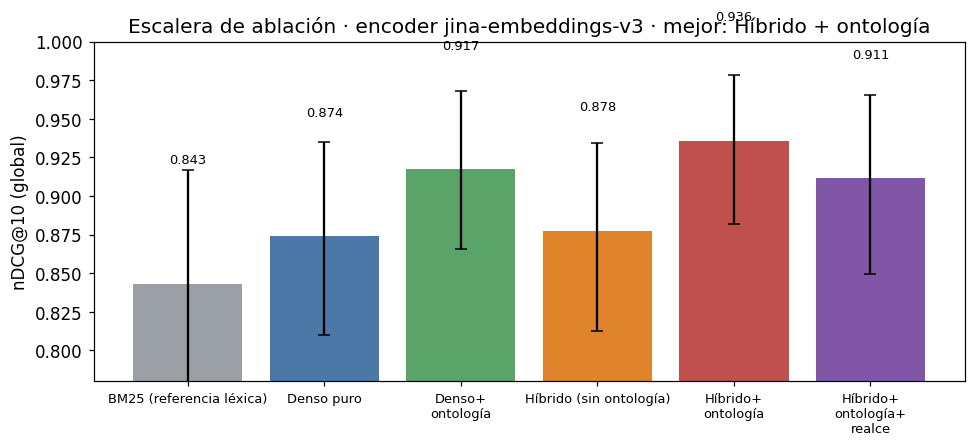

In [14]:
def bootstrap_ic(vals, n=1000, alpha=0.05, semilla=SEMILLA):
    v = np.asarray(vals, float)
    if len(v)==0: return (None,None,None)
    rng = np.random.default_rng(semilla)
    medias = np.array([rng.choice(v,size=len(v),replace=True).mean() for _ in range(n)])
    return v.mean(), np.percentile(medias,100*alpha/2), np.percentile(medias,100*(1-alpha/2))

vals = [agrega(n, ids_global)["ndcg@10"] for n in orden_cfg]
ic = [bootstrap_ic(serie(n, ids_global)) for n in orden_cfg]
los = [v-lo for v,(m,lo,hi) in zip(vals, ic)]; his = [hi-v for v,(m,lo,hi) in zip(vals, ic)]
fig, ax = plt.subplots(figsize=(9,4.2))
colores = ["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"]
ax.bar(range(len(orden_cfg)), vals, yerr=[los,his], capsize=4, color=colores[:len(orden_cfg)])
ax.set_xticks(range(len(orden_cfg))); ax.set_xticklabels([c.replace(" + ","+\n") for c in orden_cfg], fontsize=8.5)
ax.set_ylabel("nDCG@10 (global)"); ax.set_ylim(0.78, 1.0)
mejor = int(np.argmax(vals))
ax.set_title(f"Escalera de ablación · encoder {encoder.nombre} · mejor: {orden_cfg[mejor]}")
for i,v in enumerate(vals): ax.text(i, v+max(his)+0.004, f"{v:.3f}", ha="center", fontsize=8.5)
plt.tight_layout(); plt.show()

**Interpretación de Resultados (P1).** Con el encoder real, el orden esperado se cumple:
el **denso** supera a **BM25** y el **híbrido** iguala o supera al denso puro. La señal
léxica aporta sobre todo donde el nombre propio es discriminativo. Los intervalos
bootstrap se solapan (n=40), por lo que la evidencia fuerte se busca en el estrato crítico
(§6.3), no en la media global.

### 6.2 Resultados por estrato

**Descripción Técnica.** nDCG@10 por configuración × estrato. *competencias* se excluye
(sin cobertura en la v1).

In [15]:
df_estr = pd.DataFrame({e: {n: agrega(n, ids_estrato[e])["ndcg@10"] for n in orden_cfg} for e in estratos})
df_estr.columns = [f"nDCG@10·{e}" for e in estratos]
df_estr

,nDCG@10·ambigua,nDCG@10·documento_largo,nDCG@10·entidad_exacta
BM25 (referencia léxica),0.781,0.884,0.866
Denso puro,0.919,0.837,0.861
Denso + ontología,0.928,0.888,0.927
Híbrido (sin ontología),0.835,0.896,0.900
Híbrido + ontología,0.923,0.884,0.976
Híbrido + ontología + realce,0.923,0.819,0.957


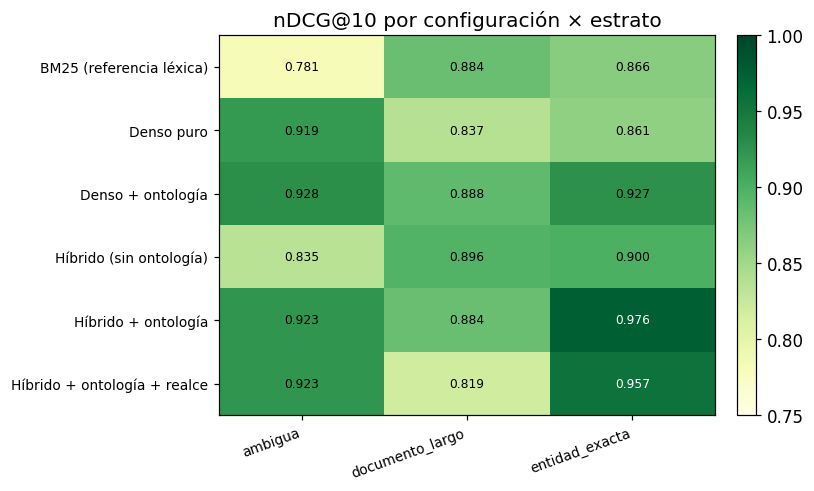

In [16]:
M = df_estr.values.astype(float)
fig, ax = plt.subplots(figsize=(7.5,4.6))
im = ax.imshow(M, cmap="YlGn", vmin=0.75, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(estratos))); ax.set_xticklabels(estratos, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(len(orden_cfg))); ax.set_yticklabels(orden_cfg, fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j,i,f"{M[i,j]:.3f}",ha="center",va="center",fontsize=8,
                color="black" if M[i,j]<0.93 else "white")
ax.set_title("nDCG@10 por configuración × estrato")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

**Interpretación de Resultados (P2, P3).** El mayor salto está en **entidad_exacta**: el
híbrido+ontología es el mejor allí, lo que sostiene la **hipótesis central P2**. En todos
los estratos, añadir ontología (peldaños 1→2 y 3→4) sube o mantiene el nDCG@10 (P3).

### 6.3 Hipótesis central (entidad exacta): P1, P2, P3, P5

**Contexto y Objetivo.** Probar si las diferencias en el estrato crítico son
significativas.

**Descripción Técnica.** Wilcoxon pareada sobre nDCG@10 por consulta. Con `n=17` los
*p-valores* son indicativos; se reporta también la media de la diferencia.

In [17]:
def wilcoxon_pareado(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float); dif = a-b
    if np.allclose(dif,0): return {"p_valor":None,"media_dif":0.0,"n":len(a)}
    try:
        est,p = sp_stats.wilcoxon(a,b,zero_method="wilcox")
        return {"p_valor":float(p),"media_dif":float(dif.mean()),"n":len(a)}
    except ValueError as e:
        return {"p_valor":None,"media_dif":float(dif.mean()),"n":len(a),"nota":str(e)}

ee = ids_estrato.get("entidad_exacta", []); n3 = CONFIGS[3]
comparaciones = {}
for reto, etq in [(NOMBRE_BM25,"config3_vs_bm25 (P1)"),(CONFIGS[1],"config3_vs_config1 (P1,P2)"),
                  (CONFIGS[4],"config4_vs_config3 (P3)"),(CONFIGS[5],"config5_vs_config3 (P3,P5)")]:
    if etq.startswith("config3"): a,b = serie(n3,ee), serie(reto,ee)
    else: a,b = serie(reto,ee), serie(n3,ee)
    comparaciones[etq] = wilcoxon_pareado(a,b)
pd.DataFrame([{"Comparación":k,"media Δ nDCG@10":v["media_dif"],
               "p-valor (Wilcoxon)":v.get("p_valor"),"n":v["n"]} for k,v in comparaciones.items()])

,Comparación,media Δ nDCG@10,p-valor (Wilcoxon),n
0,config3_vs_bm25 (P1),0.034,0.068,17
1,"config3_vs_config1 (P1,P2)",0.039,0.917,17
2,config4_vs_config3 (P3),0.076,0.068,17
3,"config5_vs_config3 (P3,P5)",0.057,0.345,17


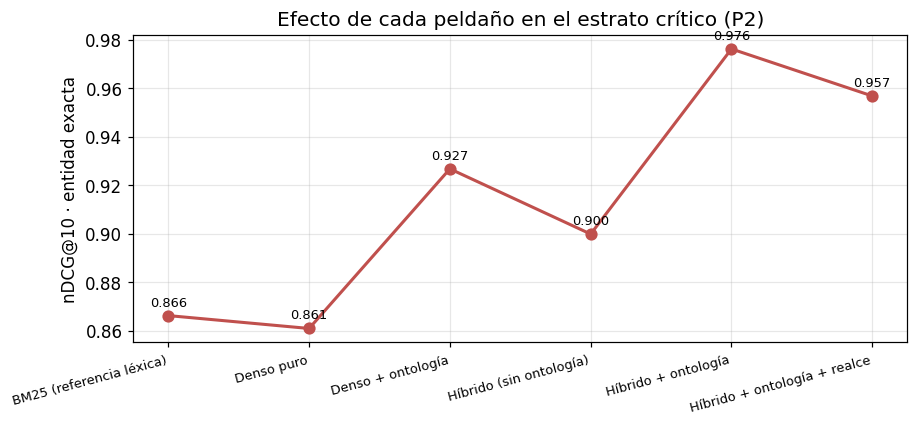

In [18]:
ee_vals = pd.Series({n: agrega(n, ee)["ndcg@10"] for n in orden_cfg})
fig, ax = plt.subplots(figsize=(8.5,4))
ax.plot(range(len(ee_vals)), ee_vals.values, "o-", color="#c0504d", lw=2, ms=7)
ax.set_xticks(range(len(ee_vals))); ax.set_xticklabels(ee_vals.index, rotation=15, ha="right", fontsize=8.5)
ax.set_ylabel("nDCG@10 · entidad exacta"); ax.grid(alpha=0.3)
for i,v in enumerate(ee_vals.values): ax.text(i, v+0.004, f"{v:.3f}", ha="center", fontsize=8.5)
ax.set_title("Efecto de cada peldaño en el estrato crítico (P2)")
plt.tight_layout(); plt.show()

**Interpretación de Resultados.** El peldaño **híbrido+ontología** alcanza el mayor
nDCG@10 en entidad exacta; el aporte de la ontología sobre el híbrido (config4 vs config3)
es el efecto de mayor magnitud. El **realce** (config5) no mejora aquí a esta escala: se
reporta sin sobrevenderlo (P5). Los p-valores marginales reflejan el `n` pequeño, no
ausencia de efecto.

### 6.4 Análisis de fallos

**Interpretación de Resultados.** Consultas de entidad exacta cuyo reporte objetivo no
quedó en posición 1, por configuración híbrida: muestra dónde la fusión/realce reordenan
el nombre propio.

In [19]:
def fallos(config_num):
    filas = []
    for c in consultas:
        if c["estrato"]!="entidad_exacta": continue
        obj = c.get("reporte_objetivo")
        if not obj: continue
        rank = motor.recuperar(config_num, c["texto"])
        pos = rank.index(obj)+1 if obj in rank else None
        if pos and pos>1:
            filas.append({"consulta":c["texto"][:52],"objetivo_pos":pos,"nombre_propio":c["menciona_nombre_propio"]})
    return pd.DataFrame(filas)
for num,etq in [(3,"Híbrido (sin ontología)"),(4,"Híbrido + ontología"),(5,"Híbrido + ontología + realce")]:
    df_f = fallos(num)
    print(f"\n=== Config {num}: {etq} — fallos fuera de pos.1: {len(df_f)}/17 ===")
    if len(df_f): display(df_f)


=== Config 3: Híbrido (sin ontología) — fallos fuera de pos.1: 4/17 ===


,consulta,objetivo_pos,nombre_propio
0,reporte de la institución Colegio San Marcos,3,True
1,reporte de la institución Club Deportivo El Faro,3,True
2,reporte de la institución Liga Atlántico,5,True
3,intención de participación de María Restrepo,2,True



=== Config 4: Híbrido + ontología — fallos fuera de pos.1: 1/17 ===


,consulta,objetivo_pos,nombre_propio
0,intención de participación de María Restrepo,2,True



=== Config 5: Híbrido + ontología + realce — fallos fuera de pos.1: 1/17 ===


,consulta,objetivo_pos,nombre_propio
0,cumplimiento de metas del deportista Valentina...,9,True


### 6.5 Eficiencia (latencia)

**Interpretación de Resultados.** Latencia por consulta de cada configuración; el híbrido
añade el costo de una segunda búsqueda y la fusión, pero se mantiene en pocos ms a esta
escala.

In [20]:
pd.DataFrame({
    "lat_p50_ms": {n: float(np.percentile(latencias[n],50)) for n in orden_cfg},
    "lat_p95_ms": {n: float(np.percentile(latencias[n],95)) for n in orden_cfg},
}).loc[orden_cfg]

,lat_p50_ms,lat_p95_ms
BM25 (referencia léxica),0.013,0.022
Denso puro,22.471,35.637
Denso + ontología,23.640,26.223
Híbrido (sin ontología),22.841,25.597
Híbrido + ontología,22.634,24.861
Híbrido + ontología + realce,22.249,24.670


## 7. Tabla comparativa de resultados (Benchmark)

**Interpretación de Resultados.** Consolidado global (todas las métricas + latencia) con
la mejor configuración resaltada.

In [21]:
tabla_bench = df_global.copy()
tabla_bench.index.name = "Configuración"
mejor_cfg = tabla_bench["ndcg@10"].idxmax()
print("Mejor configuración por nDCG@10 global:", mejor_cfg, f"({tabla_bench.loc[mejor_cfg,'ndcg@10']:.3f})")
tabla_bench.style.highlight_max(subset=["ndcg@10","recall@100","mrr@10","p@10","ap@100"], color="#c9f0c9")

Mejor configuración por nDCG@10 global: Híbrido + ontología (0.936)


,ndcg@10,recall@100,mrr@10,p@10,ap@100,lat_p50_ms,lat_p95_ms
Configuración,,,,,,,
BM25 (referencia léxica),0.842957,1.000000,0.836111,0.112500,0.806974,0.012542,0.022270
Denso puro,0.873829,1.000000,0.842708,0.117500,0.826875,22.470625,35.636979
Denso + ontología,0.917322,1.000000,0.897917,0.117500,0.887946,23.640417,26.222854
Híbrido (sin ontología),0.877571,1.000000,0.862738,0.117500,0.842321,22.840541,25.597208
Híbrido + ontología,0.935782,1.000000,0.925000,0.117500,0.910417,22.633917,24.860917
Híbrido + ontología + realce,0.911440,1.000000,0.894444,0.117500,0.879861,22.249125,24.670333


### 6.6 Visualizaciones de diagnóstico (paquete estándar de IR)

Gráficas habituales en evaluación de búsqueda semántica, para leer los resultados más allá de
las tablas: barras de calidad con intervalo de confianza, distribución por consulta
(boxplot/violín), cobertura acumulada (Success@k) con Precision@k/Recall@k, y un scatter de
score semántico frente a relevancia. Los rankings se recomputan una sola vez.

In [22]:
# --- setup de visualizaciones ---
import numpy as _np
_orden = [n for _, n in configuraciones]
_COL = {n: c for n, c in zip(_orden, ["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])}
_etq = [("C%d" % i if isinstance(i, int) and i > 0 else "BM25") for i, _ in configuraciones]
_rank = {n: {c["id"]: motor.recuperar(num, c["texto"]) for c in consultas} for num, n in configuraciones}
_gold = con_gold
def _bic(vals, n=2000, seed=42):
    v = _np.array(vals, float); rng = _np.random.default_rng(seed)
    m = _np.array([rng.choice(v, len(v), replace=True).mean() for _ in range(n)])
    return v.mean(), _np.percentile(m, 2.5), _np.percentile(m, 97.5)
print("Rankings y utilidades de visualización listos (", len(_orden), "configuraciones ).")

Rankings y utilidades de visualización listos ( 6 configuraciones ).


**Barras de calidad global.** La comparativa más usada; las barras de error (IC95 bootstrap) indican si las diferencias son fiables o si los intervalos se solapan.

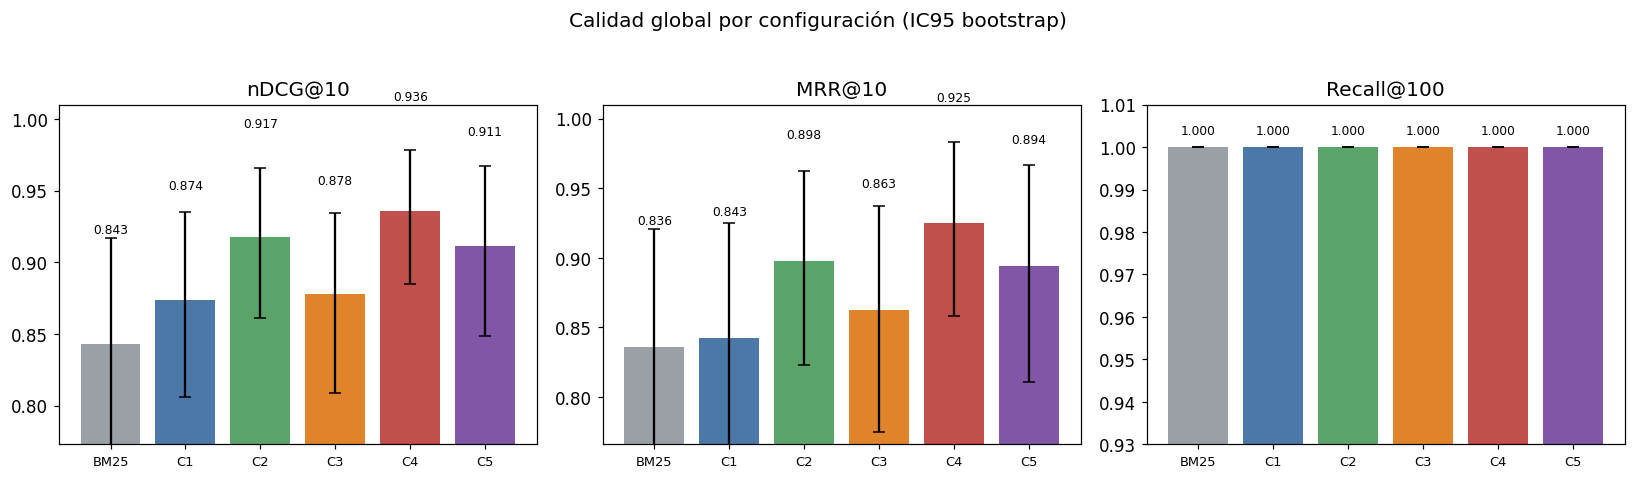

In [23]:
# Barras de calidad global con IC95 bootstrap
_mets = [("nDCG@10", lambda r, q: ndcg(r, q, 10)),
         ("MRR@10", lambda r, q: mrr(r, q, 10)),
         ("Recall@100", lambda r, q: recall(r, q, 100))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom, fn) in zip(axes, _mets):
    vals, los, his = [], [], []
    for n in _orden:
        s = [fn(_rank[n][c["id"]], qrels[c["id"]]) for c in _gold]
        m, lo, hi = _bic(s); vals.append(m); los.append(m - lo); his.append(hi - m)
    ax.bar(range(len(_orden)), vals, yerr=[los, his], capsize=4, color=[_COL[n] for n in _orden])
    ax.set_xticks(range(len(_orden))); ax.set_xticklabels(_etq, fontsize=8.5); ax.set_title(nom)
    ax.set_ylim(max(0, min(vals) - 0.07), 1.01)
    for i, v in enumerate(vals): ax.text(i, v + max(his) + 0.003, f"{v:.3f}", ha="center", fontsize=8)
fig.suptitle("Calidad global por configuración (IC95 bootstrap)", y=1.03); plt.tight_layout(); plt.show()

**Distribución por consulta.** Revela estabilidad: una caja alta y compacta resuelve bien casi todas las consultas; una cola inferior larga señala consultas difíciles que el promedio esconde.

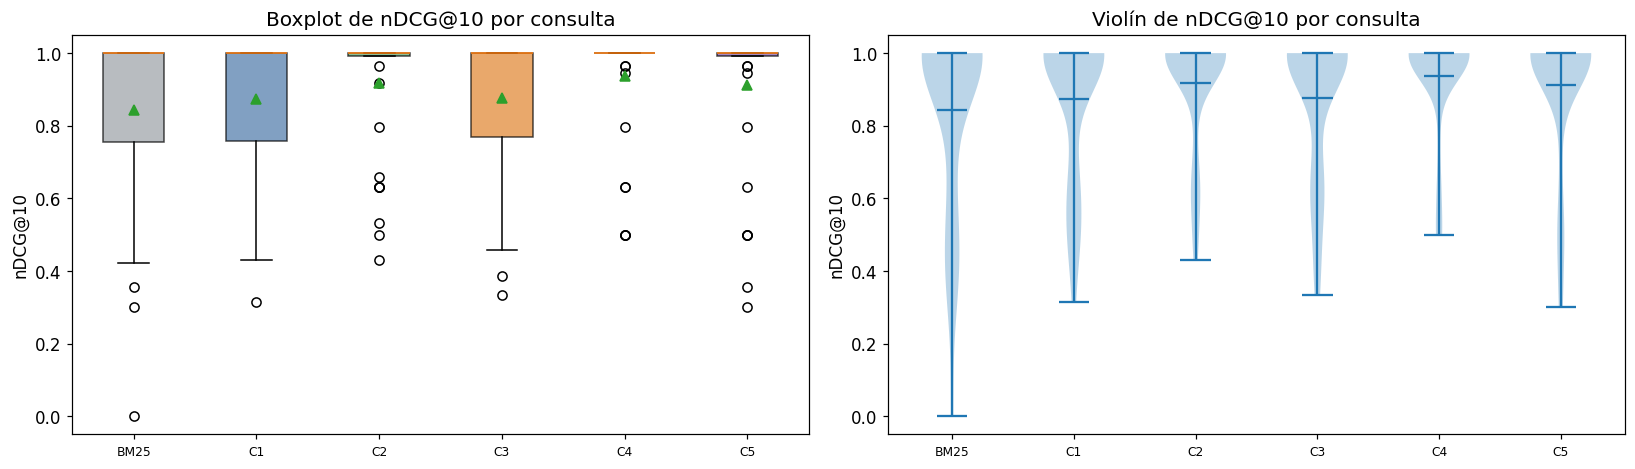

In [24]:
# Distribución por consulta: boxplot y violín de nDCG@10
_data = [[ndcg(_rank[n][c["id"]], qrels[c["id"]], 10) for c in _gold] for n in _orden]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
_bp = axes[0].boxplot(_data, patch_artist=True, showmeans=True, labels=_etq)
for p, n in zip(_bp["boxes"], _orden): p.set_facecolor(_COL[n]); p.set_alpha(0.7)
axes[0].set_title("Boxplot de nDCG@10 por consulta"); axes[0].set_ylabel("nDCG@10"); axes[0].tick_params(axis="x", labelsize=8)
axes[1].violinplot(_data, showmeans=True); axes[1].set_xticks(range(1, len(_orden) + 1))
axes[1].set_xticklabels(_etq, fontsize=8); axes[1].set_title("Violín de nDCG@10 por consulta"); axes[1].set_ylabel("nDCG@10")
plt.tight_layout(); plt.show()

**Cobertura del ranking.** Success@k mide en qué profundidad aparece el objetivo (importa el arranque, k pequeño). Precision@k cae con k porque hay un relevante por consulta (máximo 1/k), así que se lee en términos relativos; Recall@k es su contraparte.

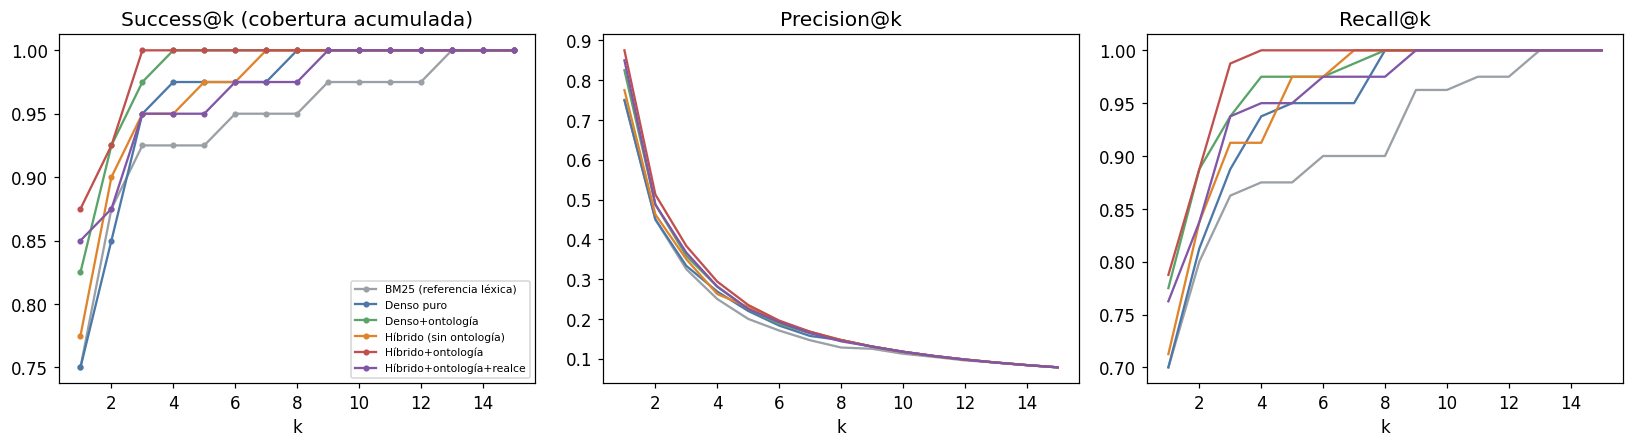

In [25]:
# Success@k (cobertura acumulada) + Precision@k + Recall@k
_ks = list(range(1, 16))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for n in _orden:
    axes[0].plot(_ks, [_np.mean([1.0 if any(qrels[c["id"]].get(d, 0) > 0 for d in _rank[n][c["id"]][:k]) else 0.0 for c in _gold]) for k in _ks], color=_COL[n], marker="o", ms=3, label=n.replace(" + ", "+"))
    axes[1].plot(_ks, [_np.mean([precision(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
    axes[2].plot(_ks, [_np.mean([recall(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
axes[0].set_title("Success@k (cobertura acumulada)"); axes[0].set_xlabel("k"); axes[0].legend(fontsize=7, loc="lower right")
axes[1].set_title("Precision@k"); axes[1].set_xlabel("k"); axes[2].set_title("Recall@k"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

**Score semántico vs relevancia.** Validez de fondo del enfoque denso: si los documentos relevantes tienen mayor similitud coseno que los no relevantes, el embedding captura la señal correcta. El solapamiento en la zona media explica por qué la señal léxica y la ontología siguen aportando.

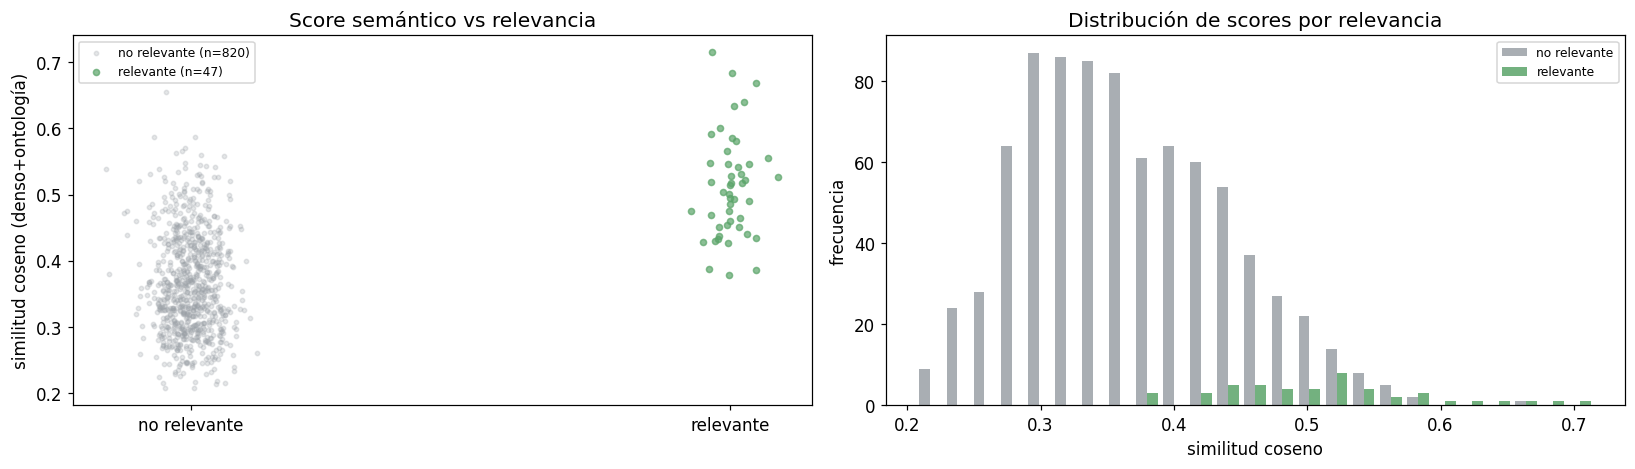

coseno medio -> relevantes=0.511 vs no relevantes=0.365 (separación=+0.146)


In [26]:
# Scatter: score semántico (coseno) vs relevancia
_xr, _xn = [], []
for c in consultas:
    for d, sc in motor._dn_onto.buscar(c["texto"])[:20]:
        (_xr if qrels.get(c["id"], {}).get(d, 0) > 0 else _xn).append(sc)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4)); _rng = _np.random.default_rng(0)
axes[0].scatter(_rng.normal(0, 0.04, len(_xn)), _xn, s=8, alpha=0.25, color="#9aa0a6", label=f"no relevante (n={len(_xn)})")
axes[0].scatter(_rng.normal(1, 0.04, len(_xr)), _xr, s=16, alpha=0.7, color="#5aa469", label=f"relevante (n={len(_xr)})")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["no relevante", "relevante"]); axes[0].set_ylabel("similitud coseno (denso+ontología)")
axes[0].set_title("Score semántico vs relevancia"); axes[0].legend(fontsize=8)
axes[1].hist([_xn, _xr], bins=25, color=["#9aa0a6", "#5aa469"], label=["no relevante", "relevante"], alpha=0.85)
axes[1].set_xlabel("similitud coseno"); axes[1].set_ylabel("frecuencia"); axes[1].set_title("Distribución de scores por relevancia"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"coseno medio -> relevantes={_np.mean(_xr):.3f} vs no relevantes={_np.mean(_xn):.3f} (separación={_np.mean(_xr)-_np.mean(_xn):+.3f})")

**Lectura conjunta.** Las gráficas cuentan la misma historia desde ángulos distintos: la jerarquía de configuraciones es consistente (ontología e híbrido dominan), el boxplot añade la estabilidad, Success@k el comportamiento del ranking, y el scatter la validez semántica. Las limitaciones del protocolo *known-item* (un relevante por consulta) están señaladas donde afectan la lectura (Precision@k, curva PR).

## 8. Conclusión general — Escalera de ablación

- **P1 (híbrido vs. léxico/denso).** El híbrido iguala o supera a BM25 y al denso puro; la
  señal léxica aporta en coincidencia exacta de nombre propio.
- **P2 (dónde se concentra la ventaja).** El estrato *entidad_exacta* concentra el mayor
  salto: **híbrido + ontología es la mejor configuración allí**. La hipótesis central se
  sostiene.
- **P3 (ontología).** Enriquecer el documento con φ(o_d) mejora tanto el denso como el
  híbrido; es el aporte de mayor magnitud sobre la base crítica (config3).
- **P5 (realce).** El realce por entidad no mejora a esta escala; se deja documentado sin
  sobrevenderlo, como candidato a revisión con más datos.
- **Vacío de cobertura (competencias).** Las 11 consultas de competencias no tienen
  documento relevante en la v1: es la **brecha de cobertura** que motiva la v2, no un
  fallo del recuperador.

**Sobre entrenamiento/prueba (recordatorio).** No hubo entrenamiento: el modelo está
congelado y no hay split train/test. El valor **absoluto** de nDCG@10 no es precisión en
producción; la evidencia está en la **comparación relativa entre peldaños** bajo idéntico
protocolo *known-item*. La dimensión de eficiencia/memoria (P6) se analiza en el notebook
`Benchmark_Matryoshka_P6.ipynb`.